In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats
import statsmodels.stats.multitest as multitest

sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")
dual = ['#B9529F','gray']
triple = ['gray','Tab:red', 'Tab:blue']
triple_ff = ['gray', 'Tab:red','Tab:blue']
sixtus = ['gray', 'Tab:red', 'Tab:blue','gray', 'Tab:red', 'gray']
seven = ['gray', 'Tab:red', 'Tab:blue','gray', 'gray', 'Tab:red', 'Tab:red']
nine = ['gray', 'Tab:red', 'Tab:blue','gray', 'gray', 'Tab:red', 'Tab:red', 'Tab:red', 'Tab:red']
npy = ['gray','darkgreen']
agrp = ['gray','tab:brown']

In [2]:
def preprocess_plot(df, cat_name , name,  palette, order, plotting = False):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        
        else:
            param_df = df
        
        try:
            unique_cat = df[cat_name].unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:
                should_plot = False
                # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
                #                     equal_var = False)

                _, p = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna())
            
                print(column, combo, p)
               

           
        except ValueError:
            
            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())
                

                sns.set(rc={"figure.figsize": (3, 3)})
                sns.set(font_scale=2.5) 
                sns.set_style("ticks")

                ax = sns.boxplot(x=cat_name, y=column, data = param_df, order = order, palette = palette, 
                                saturation=8, linewidth=1.7, showfliers = False, boxprops=dict(alpha=0.5))
                ax = sns.stripplot(x=cat_name, y=column, data = param_df, order=order, 
                                jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = palette, alpha=0.5, zorder=0)
                ax.set_xlabel('')
                ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-',  'Y-KD') , rotation=45)
                ax.yaxis.set_major_locator(plt.MaxNLocator(2))
                plt.ylabel(column.replace('_', ' '))

                sns.despine()
                
                plt.savefig(f'output_figures/{column}.png',
                    dpi=300,bbox_inches='tight', transparent=True)
                plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{column}.pdf',
                    dpi=300,bbox_inches='tight', transparent=True)
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# Ephys analysis

In [3]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

include_gal = True

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
# df.loc[df.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)


cat = df.Behaviour_6hFD.unique()

if include_gal:
       gal = df[(df.Gal_positive == 'yes') & (df.Behaviour_6hFD == 'Pre')] 
       no_gal = df[(df.Gal_positive == 'no') & (df.Behaviour_6hFD == 'Pre')]
       
       ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[(df.Gal_positive == 'Unknown') & (df.Behaviour_6hFD != 'Pre')]])
       sample_num= int(no_gal.shape[0]/4)
       ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 62)]).reset_index(drop = True)

else:
       ephys = df[df.Gal_positive == 'Unknown']
  
# ephys.loc[ephys.Behaviour_6hFD.isin([ 'npy_100_paired']),'Behaviour_6hFD'] = 'npy_100'
     
# ephys.loc[ephys.Behaviour_6hFD.isin(['npy_10', 'npy_100']),'Behaviour_6hFD'] = 'npy'

ephys.to_csv('sampled_ephys_data.csv')

In [4]:
behav = pd.read_csv('ephys_behav.csv')
ephys_behav = pd.merge(ephys, behav, on  = 'ID_mouse')
ephys_behav.columns = [col.replace('(', '_').replace(')', '_') for col in ephys_behav.columns]
ephys_behav.columns = [col.replace(' ', '_').replace('-', '_') for col in ephys_behav.columns]

In [5]:
percent_columns = ['Ih_at__120mV', 'CaT', 'Adaptive', 'Firing_freq__Hz__I0'] 
percentages_df = pd.DataFrame(index=ephys_behav['ID_mouse'].unique())

for column in percent_columns:
    percentages = ephys_behav.groupby('ID_mouse')[column].apply(lambda x: (x == 0).sum() / len(x) * 100)
    percentages_df[column + '_percent_nonzero'] = percentages

silent_percentages = ephys_behav.groupby('ID_mouse')['I_zero_reclassified'].apply(lambda x: (x == 'silent').sum() / len(x) * 100).reset_index(name='I_zero_reclassified' + '_percent_silent')
percentages_df = percentages_df.reset_index()
percentages_df.rename(columns={'index': 'ID_mouse'}, inplace=True)
percentages_df = pd.merge(percentages_df, silent_percentages, on='ID_mouse', how='outer')

percentages_df = pd.merge(percentages_df, behav, on = 'ID_mouse')




In [6]:
for y in percentages_df.columns[1:-6]:
    if y != 'attack_since_contact':  # Skip the contact_latency column
        formula = 'attack_since_contact ~ ' + y
        try:
            model = smf.ols(formula, data=percentages_df).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_since_contact', y = y, data = percentages_df)
           
        except Exception as e:
            continue

0.019449281049281487 sPSC_Amplitude_pA_ 0.31337716718782105


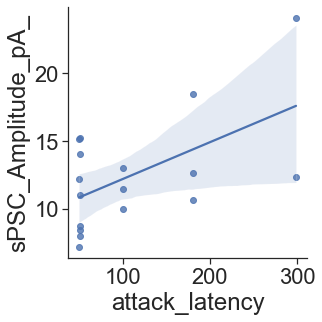

In [7]:
#ephys correlation with behaviour metric
for y in ephys_behav.columns[8:-8]:
    if y != 'contact_latency':  # Skip the contact_latency column
        formula = 'attack_latency ~ ' + y
        try:
            model = smf.ols(formula, data=ephys_behav).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_latency', y = y, data = ephys_behav)
                plt.show()
           
        except Exception as e:
            continue
    

In [8]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

## All properties

In [9]:
# filter_cat = ['Pre', 'Agg+', 'Agg-', 'npy_10', 'npy_antag', 'npy1r_antag', 'npy2r_antag' ,'ZD7288']

# # set categorical variables
# ephys['Behaviour_6hFD'] = pd.Categorical(ephys['Behaviour_6hFD'], categories=filter_cat, ordered=True)


# preprocess_plot(ephys[ephys.Behaviour_6hFD.isin(filter_cat)],'Behaviour_6hFD', 'pan', 
#                 palette=['Gray', 'Tab:red', 'Tab:Blue', 'Gray', 'Tab:red', 'Tab:red', 'Gray'], order = filter_cat,
#                   plotting= True)


## Individual plots - panMPOA

In [10]:
# subset df for those groups needed for firing freq. plot
ephys2 = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg-') |(ephys['Behaviour_6hFD'] == 'Agg+')]

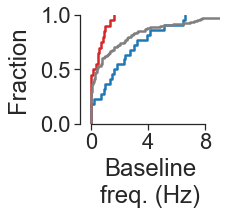

In [11]:
# Firing frequency

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = triple_ff, linewidth=2.5, legend=False,
                   stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [12]:
# Stats
ephys2_pre = ephys2.loc[ephys2['Behaviour_6hFD'] == 'Pre', 'Firing_freq_(Hz)_I0'].dropna()
ephys2_agg = ephys2.loc[ephys2['Behaviour_6hFD'] == 'Agg+', 'Firing_freq_(Hz)_I0'].dropna()
ephys2_noagg = ephys2.loc[ephys2['Behaviour_6hFD'] == 'Agg-', 'Firing_freq_(Hz)_I0'].dropna()

from scipy.stats import mannwhitneyu

# Pre vs Agg+
u_statistic, p_value = mannwhitneyu(ephys2_pre, ephys2_agg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Pre vs Agg+:", p_value)
# Pre vs Agg-
u_statistic, p_value = mannwhitneyu(ephys2_pre, ephys2_noagg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Pre vs Agg-:", p_value)
# Agg- vs Agg+
u_statistic, p_value = mannwhitneyu(ephys2_noagg, ephys2_agg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Agg- vs Agg+:", p_value)

Mann-Whitney U Statistic: 1328.0
P-value Pre vs Agg+: 0.05827899141391609
Mann-Whitney U Statistic: 850.0
P-value Pre vs Agg-: 0.050500440681557957
Mann-Whitney U Statistic: 352.5
P-value Agg- vs Agg+: 0.0007392103156646884


In [21]:
# stats - one-way ANOVA
from scipy.stats import f_oneway

filtered_groups = ['Pre', 'Agg+', 'Agg-']
ephys_filtered = ephys2[ephys2['Behaviour_6hFD'].isin(filtered_groups)]
ephys_filtered = ephys_filtered.dropna(subset=['Behaviour_6hFD', 'Firing_freq_(Hz)_I0'])
groups = ephys_filtered.groupby('Behaviour_6hFD')['Firing_freq_(Hz)_I0'].apply(lambda x: x.dropna().tolist())
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

# Tukey HSD
tukey_results = pairwise_tukeyhsd(ephys_filtered['Firing_freq_(Hz)_I0'], ephys_filtered['Behaviour_6hFD'])
print(tukey_results)

One-way ANOVA p-value: 0.043543836800807964
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Agg+   Agg-   1.7918 0.0413  0.0565 3.5271   True
  Agg+    Pre   1.2215 0.0912 -0.1488 2.5918  False
  Agg-    Pre  -0.5703  0.562 -1.8872 0.7467  False
---------------------------------------------------


In [ ]:
# subset df for those groups needed for firing freq. plot - ALL GROUPS
ephys2_all = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg-') |(ephys['Behaviour_6hFD'] == 'Agg+') |
                      (ephys['Behaviour_6hFD'] == 'npy_antag') | (ephys['Behaviour_6hFD'] == 'npy_KD_dummy') |(ephys['Behaviour_6hFD'] == 'ZD7288')]

In [ ]:
# Firing frequency - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2_all, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = sixtus, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# Membrane voltage / RMP

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
ephys.Behaviour_6hFD.unique()

In [ ]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-', 'ZD','NPY','Ant-Y', 'KD-Y'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS INCL. Y1/Y2 ANT

sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = nine)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = nine, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-', 'ZD','NPY','Ant-Y','Ant-Y1','Ant-Y2','KD-Y'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_all_Y12.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# STATS ====================================================================

# even though results are grouped in these plots, these are separate experiments, i.e. (1) Pre vs Agg- vs Agg+, (2) Pre vs ZD, Pre vs NPY,
# (3) Agg+ vs Ant-Y, (Agg+ vs Ant-Y1, Agg+ vs Ant-Y2), Agg+ vs KD-Y --> for (1) use ANOVA w/ Tukey; 
# for (2) and (3) use U test w/ Benjamini-Hochberg correction

# (1) ANOVA (Pre, Agg+, Agg-) ===============================================

group_summary = ephys.groupby('Behaviour_6hFD')['Vm'].agg(['count', 'var'])
# print(group_summary)

# filter for the groups we want
groups_to_include = ['Pre', 'Agg+', 'Agg-'] # , 'ZD7288', 'npy_100', 'npy_antag', 'npykd'
ephys2 = ephys[ephys['Behaviour_6hFD'].isin(groups_to_include)]

# Ensure 'Vm' is numeric and 'Behaviour_6hFD' is categorical
ephys2['Vm'] = pd.to_numeric(ephys2['Vm'], errors='coerce')
ephys2['Behaviour_6hFD'] = ephys2['Behaviour_6hFD'].astype('category')

# Drop rows with missing 'Vm' values
ephys2 = ephys2.dropna(subset=['Vm'])

# One-way ANOVA
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

if all(group_summary['count'] > 1) and all(group_summary['var'] > 0):
    anova_result = f_oneway(
        ephys2['Vm'][ephys2['Behaviour_6hFD'] == 'Pre'],
        ephys2['Vm'][ephys2['Behaviour_6hFD'] == 'Agg+'],
        ephys2['Vm'][ephys2['Behaviour_6hFD'] == 'Agg-']
    )

    print("One-way ANOVA p-value:", anova_result.pvalue)

    # Tukey HSD test for multiple comparisons
    tukey_results = pairwise_tukeyhsd(ephys2['Vm'], ephys2['Behaviour_6hFD'])
    print(tukey_results)
else:
    print("Not all groups have sufficient data or variance for ANOVA.")
    
# (2) U test: Pre vs ZD, Pre vs NPY ==========================================

group_pre = ephys[ephys['Behaviour_6hFD'] == 'Pre']['Vm'].dropna()
group_zd = ephys[ephys['Behaviour_6hFD'] == 'ZD7288']['Vm'].dropna()
group_npy = ephys[ephys['Behaviour_6hFD'] == 'npy_100']['Vm'].dropna()

u_statistic2, p_value2 = mannwhitneyu(group_pre, group_zd)
u_statistic3, p_value3 = mannwhitneyu(group_pre, group_npy)

# Benjamini-Hochberg correction
from statsmodels.stats.multitest import multipletests
p_values = [p_value2, p_value3]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Pre' and 'ZD7288': {p_value2}")
print(f"Mann-Whitney U test between 'Pre' and 'NPY': {p_value3}")
print("Corrected p-values:", p_adjusted)

# (3) U test: Agg+ vs Ant-Y, Agg+ vs Ant-Y1, Agg+ vs Ant-Y2, Agg+ vs KD-Y ==========================================

group_agg = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['Vm'].dropna()
group_ant = ephys[ephys['Behaviour_6hFD'] == 'npy_antag']['Vm'].dropna()
group_ant1 = ephys[ephys['Behaviour_6hFD'] == 'npy1r_antag']['Vm'].dropna()
group_ant2 = ephys[ephys['Behaviour_6hFD'] == 'npy2r_antag']['Vm'].dropna()
group_kd = ephys[ephys['Behaviour_6hFD'] == 'npykd']['Vm'].dropna()

u_statistic4, p_value4 = mannwhitneyu(group_agg, group_ant)
u_statistic5, p_value5 = mannwhitneyu(group_agg, group_ant1)
u_statistic6, p_value6 = mannwhitneyu(group_agg, group_ant2)
u_statistic7, p_value7 = mannwhitneyu(group_agg, group_kd)

p_values = [p_value4, p_value5, p_value6, p_value7]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Agg+' and 'Ant-Y': {p_value4}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y1': {p_value5}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y2': {p_value6}")
print(f"Mann-Whitney U test between 'Agg+' and 'KD-Y': {p_value7}")
print("Corrected p-values:", p_adjusted)

In [ ]:
# Input resistance

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats - ANOVA + Tukey
pre_group = ephys[ephys['Behaviour_6hFD'] == 'Pre']['Input_Resistance'].dropna()
agg_plus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['Input_Resistance'].dropna()
agg_minus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg-']['Input_Resistance'].dropna()

anova_result = f_oneway(pre_group, agg_plus_group, agg_minus_group)
print("One-way ANOVA p-value:", anova_result.pvalue)

all_input_resistances = np.concatenate([pre_group, agg_plus_group, agg_minus_group])
group_labels = ['Pre'] * len(pre_group) + ['Agg+'] * len(agg_plus_group) + ['Agg-'] * len(agg_minus_group)
tukey_results = pairwise_tukeyhsd(all_input_resistances, group_labels)
print(tukey_results)

In [ ]:
# Input resistance - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$', 'ZD', 'NPY' ,'Ant-Y', 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# Input resistance - VERSION WITH ALL GROUPS INCL Y1/2

sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = nine)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = nine, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$', 'ZD', 'NPY' ,'Ant-Y','Ant-Y1','Ant-Y2', 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_all_Y12.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# STATS ====================================================================

# even though results are grouped in these plots, these are separate experiments, i.e. (1) Pre vs Agg- vs Agg+, (2) Pre vs ZD, Pre vs NPY,
# (3) Agg+ vs Ant-Y, (Agg+ vs Ant-Y1, Agg+ vs Ant-Y2), Agg+ vs KD-Y --> for (1) use ANOVA w/ Tukey; 
# for (2) and (3) use U test w/ Benjamini-Hochberg correction

# (1) ANOVA (Pre, Agg+, Agg-) ===============================================

group_summary = ephys.groupby('Behaviour_6hFD')['Input_Resistance'].agg(['count', 'var'])
# print(group_summary)

# filter for the groups we want
groups_to_include = ['Pre', 'Agg+', 'Agg-'] # , 'ZD7288', 'npy_100', 'npy_antag', 'npykd'
ephys3 = ephys[ephys['Behaviour_6hFD'].isin(groups_to_include)]

# Ensure 'Input_Resistance' is numeric and 'Behaviour_6hFD' is categorical
ephys3['Input_Resistance'] = pd.to_numeric(ephys3['Input_Resistance'], errors='coerce')
ephys3['Behaviour_6hFD'] = ephys3['Behaviour_6hFD'].astype('category')

# Drop rows with missing values
ephys3 = ephys3.dropna(subset=['Input_Resistance'])

# One-way ANOVA
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

if all(group_summary['count'] > 1) and all(group_summary['var'] > 0):
    anova_result = f_oneway(
        ephys3['Input_Resistance'][ephys3['Behaviour_6hFD'] == 'Pre'],
        ephys3['Input_Resistance'][ephys3['Behaviour_6hFD'] == 'Agg+'],
        ephys3['Input_Resistance'][ephys3['Behaviour_6hFD'] == 'Agg-']
    )

    print("One-way ANOVA p-value:", anova_result.pvalue)

    # Tukey HSD test for multiple comparisons
    tukey_results = pairwise_tukeyhsd(ephys3['Input_Resistance'], ephys3['Behaviour_6hFD'])
    print(tukey_results)
else:
    print("Not all groups have sufficient data or variance for ANOVA.")
    
# (2) U test: Pre vs ZD, Pre vs NPY ==========================================

group_pre = ephys[ephys['Behaviour_6hFD'] == 'Pre']['Input_Resistance'].dropna()
group_zd = ephys[ephys['Behaviour_6hFD'] == 'ZD7288']['Input_Resistance'].dropna()
group_npy = ephys[ephys['Behaviour_6hFD'] == 'npy_100']['Input_Resistance'].dropna()

u_statistic2, p_value2 = mannwhitneyu(group_pre, group_zd)
u_statistic3, p_value3 = mannwhitneyu(group_pre, group_npy)

# Benjamini-Hochberg correction
from statsmodels.stats.multitest import multipletests
p_values = [p_value2, p_value3]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Pre' and 'ZD7288': {p_value2}")
print(f"Mann-Whitney U test between 'Pre' and 'NPY': {p_value3}")
print("Corrected p-values:", p_adjusted)

# (3) U test: Agg+ vs Ant-Y, Agg+ vs Ant-Y1, Agg+ vs Ant-Y2, Agg+ vs KD-Y ==========================================

group_agg = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['Input_Resistance'].dropna()
group_ant = ephys[ephys['Behaviour_6hFD'] == 'npy_antag']['Input_Resistance'].dropna()
group_ant1 = ephys[ephys['Behaviour_6hFD'] == 'npy1r_antag']['Input_Resistance'].dropna()
group_ant2 = ephys[ephys['Behaviour_6hFD'] == 'npy2r_antag']['Input_Resistance'].dropna()
group_kd = ephys[ephys['Behaviour_6hFD'] == 'npykd']['Input_Resistance'].dropna()

u_statistic4, p_value4 = mannwhitneyu(group_agg, group_ant)
u_statistic5, p_value5 = mannwhitneyu(group_agg, group_ant1)
u_statistic6, p_value6 = mannwhitneyu(group_agg, group_ant2)
u_statistic7, p_value7 = mannwhitneyu(group_agg, group_kd)

p_values = [p_value4, p_value5, p_value6, p_value7]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Agg+' and 'Ant-Y': {p_value4}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y1': {p_value5}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y2': {p_value6}")
print(f"Mann-Whitney U test between 'Agg+' and 'KD-Y': {p_value7}")
print("Corrected p-values:", p_adjusted)

In [ ]:
# cell numbers
group_counts = ephys['Behaviour_6hFD'].value_counts()
# print(group_counts)
# mice per group
unique_id_counts = ephys.groupby('Behaviour_6hFD')['ID_mouse'].nunique()
# print(unique_id_counts)

In [ ]:
# Ih
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# Ih - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$','ZD','NPY','Ant-Y', 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# Ih - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = nine)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = nine, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$','ZD','NPY','Ant-Y','Ant-Y1','Ant-Y2' ,'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ih_all_Y12.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# STATS ====================================================================

# even though results are grouped in these plots, these are separate experiments, i.e. (1) Pre vs Agg- vs Agg+, (2) Pre vs ZD, Pre vs NPY,
# (3) Agg+ vs Ant-Y, (Agg+ vs Ant-Y1, Agg+ vs Ant-Y2), Agg+ vs KD-Y --> for (1) use ANOVA w/ Tukey; 
# for (2) and (3) use U test w/ Benjamini-Hochberg correction

# (1) ANOVA (Pre, Agg+, Agg-) ===============================================

groups_to_include = ['Pre', 'Agg+', 'Agg-'] # , 'ZD7288', 'npy_100', 'npy_antag', 'npykd'
ephys4 = ephys[ephys['Behaviour_6hFD'].isin(groups_to_include)]

# Ensure 'Ih_at_-120mV' is numeric and 'Behaviour_6hFD' is categorical
ephys4['Ih_at_-120mV'] = pd.to_numeric(ephys4['Ih_at_-120mV'], errors='coerce')
ephys4['Behaviour_6hFD'] = ephys4['Behaviour_6hFD'].astype('category')

# Drop rows with missing values
ephys4 = ephys4.dropna(subset=['Ih_at_-120mV'])

# One-way ANOVA
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

anova_result = f_oneway(
        ephys4['Ih_at_-120mV'][ephys4['Behaviour_6hFD'] == 'Pre'],
        ephys4['Ih_at_-120mV'][ephys4['Behaviour_6hFD'] == 'Agg+'],
        ephys4['Ih_at_-120mV'][ephys4['Behaviour_6hFD'] == 'Agg-']
        )

print("One-way ANOVA p-value:", anova_result.pvalue)

# Tukey HSD test for multiple comparisons
tukey_results = pairwise_tukeyhsd(ephys4['Ih_at_-120mV'], ephys4['Behaviour_6hFD'])
print(tukey_results)
    
# (2) U test: Pre vs ZD, Pre vs NPY ==========================================

group_pre = ephys[ephys['Behaviour_6hFD'] == 'Pre']['Ih_at_-120mV'].dropna()
group_zd = ephys[ephys['Behaviour_6hFD'] == 'ZD7288']['Ih_at_-120mV'].dropna()
group_npy = ephys[ephys['Behaviour_6hFD'] == 'npy_100']['Ih_at_-120mV'].dropna()

u_statistic2, p_value2 = mannwhitneyu(group_pre, group_zd)
u_statistic3, p_value3 = mannwhitneyu(group_pre, group_npy)

# Benjamini-Hochberg correction
from statsmodels.stats.multitest import multipletests
p_values = [p_value2, p_value3]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Pre' and 'ZD7288': {p_value2}")
print(f"Mann-Whitney U test between 'Pre' and 'NPY': {p_value3}")
print("Corrected p-values:", p_adjusted)

# (3) U test: Agg+ vs Ant-Y, Agg+ vs Ant-Y1, Agg+ vs Ant-Y2, Agg+ vs KD-Y ==========================================

group_agg = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['Ih_at_-120mV'].dropna()
group_ant = ephys[ephys['Behaviour_6hFD'] == 'npy_antag']['Ih_at_-120mV'].dropna()
group_ant1 = ephys[ephys['Behaviour_6hFD'] == 'npy1r_antag']['Ih_at_-120mV'].dropna()
group_ant2 = ephys[ephys['Behaviour_6hFD'] == 'npy2r_antag']['Ih_at_-120mV'].dropna()
group_kd = ephys[ephys['Behaviour_6hFD'] == 'npykd']['Ih_at_-120mV'].dropna()

u_statistic4, p_value4 = mannwhitneyu(group_agg, group_ant)
u_statistic5, p_value5 = mannwhitneyu(group_agg, group_ant1)
u_statistic6, p_value6 = mannwhitneyu(group_agg, group_ant2)
u_statistic7, p_value7 = mannwhitneyu(group_agg, group_kd)

p_values = [p_value4, p_value5, p_value6, p_value7] #p_value5, p_value6, 
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Agg+' and 'Ant-Y': {p_value4}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y1': {p_value5}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y2': {p_value6}")
print(f"Mann-Whitney U test between 'Agg+' and 'KD-Y': {p_value7}")
print("Corrected p-values:", p_adjusted)

In [ ]:
# CaT
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='CaT', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='CaT', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('CaT (mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(0, 50)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/cat.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats - ANOVA + Tukey
pre_group = ephys[ephys['Behaviour_6hFD'] == 'Pre']['CaT'].dropna()
agg_plus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['CaT'].dropna()
agg_minus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg-']['CaT'].dropna()

anova_result = f_oneway(pre_group, agg_plus_group, agg_minus_group)
print("One-way ANOVA p-value:", anova_result.pvalue)

In [ ]:
# AHP

ephys_filtered = ephys[ephys['AHP_(mV)'] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AHP_(mV)', data = ephys_filtered, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AHP_(mV)', data = ephys_filtered, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('AHP (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(-80, 0)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/ahp.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# Cm
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Cm(pF)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Cm(pF)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('Cm (pF)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(top=100)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/Cm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# AP_ampl
ephys_filt = ephys[ephys['AP_ampl'] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AP_ampl', data = ephys_filt, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AP_ampl', data = ephys_filt, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP amplitude\n(mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(0,150)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_ampl.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# AP_halfwidth
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AP_halfwidth', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AP_halfwidth', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP halfwidth\n(ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,15)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_halfwidth.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats - ANOVA + Tukey
pre_group = ephys[ephys['Behaviour_6hFD'] == 'Pre']['AP_halfwidth'].dropna()
agg_plus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['AP_halfwidth'].dropna()
agg_minus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg-']['AP_halfwidth'].dropna()

anova_result = f_oneway(pre_group, agg_plus_group, agg_minus_group)
print("One-way ANOVA p-value:", anova_result.pvalue)

In [ ]:
# AP threshold - loaded from a different excel sheet currently, but will add to main ephys.csv file
ap_thresh = pd.read_csv('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/AP threshold/APthreshold_v1.csv')

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='state', y='AP_threshold_mV', data = ap_thresh, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='state', y='AP_threshold_mV', data = ap_thresh, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP threshold\n(mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-50, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_threshold.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# rheobase_at_-60mV_(pA)
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='rheobase_at_-60mV_(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='rheobase_at_-60mV_(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('Rheobase (pA)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,150)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/rheo.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# sPSC_frequency
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSC_frequency', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSC_frequency', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC freq. (Hz)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,12)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_freq.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# sPSC_amp
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSC_Amplitude(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSC_Amplitude(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC amp. (pA)', labelpad=10)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,45)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_amp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# sPSC rise time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSCs_Rise time', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSCs_Rise time', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC rise\ntime (ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,6)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_rise.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# sPSC decay time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSCs (decay)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSCs (decay)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC decay\ntime (ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_decay.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## Gal+ vs Gal-

In [ ]:
# gal = ephys[(ephys['Gal_positive'] == 'yes') & (ephys['Behaviour_6hFD'] == 'Agg+')]
# no_gal = ephys[(ephys['Gal_positive'] == 'no') & (ephys['Behaviour_6hFD'] == 'Agg+')]
# gals = pd.concat([gal,no_gal], axis = 0)
# len(no_gal)

In [ ]:
# count_yes_agg = ((ephys['Gal_positive'] == 'yes') & (ephys['Behaviour_6hFD'] == 'Agg+')).sum()
# count_no_agg = ((ephys['Gal_positive'] == 'no') & (ephys['Behaviour_6hFD'] == 'Agg+')).sum()
# print(f"Number of Gal+ (Agg+) cells: {count_yes_agg}")
# print(f"Number of Gal- (Agg+) cells: {count_no_agg}")

In [ ]:
# preprocess_plot(ephys[(ephys.Gal_positive.isin(['no', 'yes'])) & (ephys.Behaviour_6hFD.isin(['Agg-', 'Agg+']))], 
#                 'Gal_positive', 'gal', palette=['Gray', 'Tab:red'], order = ['no', 'yes'], plotting= True)

In [47]:
trial = ephys[ephys.Behaviour_6hFD.isin(['Pre', 'Agg-', 'Agg+'])]
trial = trial.rename(columns={'Ih_at_-120mV': 'ih_current', 
                              'Firing_freq_(Hz)_I0': 'firing_freq', 
                              'sPSC_Amplitude(pA)': 'sPSC_Amplitude'})
model = smf.ols('Input_Resistance ~  ih_current  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
ih_current,2.581054e+05,1.0,5.37375,0.02303
Residual,3.794432e+06,79.0,NaN,NaN


In [48]:
print("Coefficient of determination (R^2):", model.rsquared)

Coefficient of determination (R^2): 0.06368983080676316


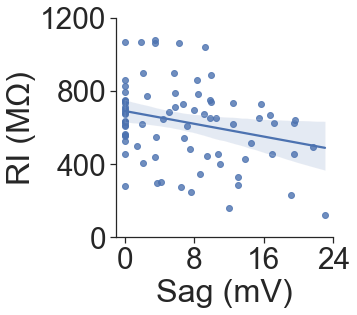

In [52]:
sns.set(font_scale=2.7) 
sns.set_style("ticks")
sns.lmplot(x = 'ih_current', y = 'Input_Resistance', data = trial, palette = ['darkgray', '#F97306', 'blue'], aspect=1.1)
plt.ylabel('RI (MΩ)')
plt.xlabel('Sag (mV)')
plt.ylim(0, 1200)
plt.yticks([0, 400, 800, 1200])
plt.xticks([0, 8, 16, 24])
plt.xlim(-1, 24)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/ih_input_resistance.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# l = 'Instant_freq_(Hz)'
# max = ephys[l].max()
# cs = ['darkgray', '#F97306', 'Tab:blue']
# conds = ['Pre', 'Agg+', 'Agg-']
# fig, ax = plt.subplots(figsize=(2, 2))
# sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
# sns.despine()
# plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

# plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
# plt.show()

### Individual plots Gal+ vs Gal-

In [ ]:
gals = df[(df.Gal_positive.isin(['yes', 'no'])) & (df.Behaviour_6hFD != 'Pre')]

In [ ]:
print(f"Number of Gal+ neurons: {(gals['Gal_positive'] == 'yes').sum()} from {gals[gals['Gal_positive'] == 'yes']['ID_mouse'].nunique()} mice")
print(f"Number of Gal- neurons: {(gals['Gal_positive'] == 'no').sum()} from {gals[gals['Gal_positive'] == 'no']['ID_mouse'].nunique()} mice")

In [ ]:
# Cm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Cm(pF)', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Cm(pF)', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Cm (pF)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0,100)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Cm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# gals

In [ ]:
# Vm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Vm', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Vm', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-60, 0)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Vm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats - U test
gal_positive_data = gals[gals['Gal_positive'] == 'yes']['Vm']
gal_negative_data = gals[gals['Gal_positive'] == 'no']['Vm']
u_statistic, p_value = mannwhitneyu(gal_positive_data, gal_negative_data)
print("Mann-Whitney U test p-value:", p_value)

In [ ]:
# RI Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Input_Resistance', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Input_Resistance', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 1600)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ri.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# Ih Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 20)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ih.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats - U test
gal_positive_sag = gals[gals['Gal_positive'] == 'yes']['Ih_at_-120mV'].dropna()
gal_negative_sag = gals[gals['Gal_positive'] == 'no']['Ih_at_-120mV'].dropna()
u_statistic, p_value = mannwhitneyu(gal_positive_sag, gal_negative_sag)
print("Mann-Whitney U test p-value:", p_value)

In [ ]:
# Firing frequency Gal+ vs Gal-
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=gals, x="Firing_freq_(Hz)_I0", hue="Gal_positive", palette = dual, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/ff.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## Silent proportion

In [ ]:
## silent proportion
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100',  'npy_antag','npy1r_antag', 'npy2r_antag', 'npykd']
silent_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero_reclassified', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], cat)
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('silent_prop')
plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

In [ ]:
# % silent neurons - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'],
                palette = seven, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$','ZD', 'NPY', 'Ant-Y', 'KD-Y'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_all.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# % silent neurons - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'],
                palette = nine, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$','ZD', 'NPY', 'Ant-Y','Ant-Y1','Ant-Y2', 'KD-Y'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_all_Y12.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats
# make contingency table (based on ephys df, not silent_prop, which only has %)
ephys2 = ephys.copy()
ephys2['I_zero_reclassified'] = ephys2['I_zero_reclassified'].replace({'phasic': 'active', 'tonic': 'active'})
contingency_table = ephys2.groupby(['Behaviour_6hFD', 'I_zero_reclassified']).size().unstack(fill_value=0)
contingency_table['active'] = contingency_table.sum(axis=1) - contingency_table.get('silent', 0)
contingency_table = contingency_table[['silent', 'active']]
print(contingency_table)

# groups = ['Agg+','Agg-','Pre','ZD7288','npy_100','npy_antag','npykd'] #'npy1r_antag','npy2r_antag',

# (1) Pre/Agg+/Agg- ==================================

groups = ['Agg+','Agg-','Pre']
p_values = []
comparisons = []
from scipy.stats import fisher_exact

# Perform Fisher's exact test between each pair of groups
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        
        # Create contingency table
        table = [
            [contingency_table.loc[group1, 'silent'], contingency_table.loc[group1, 'active']],
            [contingency_table.loc[group2, 'silent'], contingency_table.loc[group2, 'active']]
        ]
        
        # Perform Fisher's exact test
        _, p_value = fisher_exact(table)
        
        # Store the p-value and the comparison
        p_values.append(p_value)
        comparisons.append(f"{group1} vs {group2}")

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Print the results
for comp, pval, pval_corr in zip(comparisons, p_values, pvals_corrected):
    print(f"Comparison: {comp}, Original p-value: {pval:.4e}, Corrected p-value: {pval_corr:.4e}")


# (2) Pre/ZD/NPY ==================================

groups = ['Pre', 'ZD7288', 'npy_100']
p_values = []
comparisons = []
from scipy.stats import fisher_exact

# Perform Fisher's exact test between each pair of groups
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        
        # Create contingency table
        table = [
            [contingency_table.loc[group1, 'silent'], contingency_table.loc[group1, 'active']],
            [contingency_table.loc[group2, 'silent'], contingency_table.loc[group2, 'active']]
        ]
        
        # Perform Fisher's exact test
        _, p_value = fisher_exact(table)
        
        # Store the p-value and the comparison
        p_values.append(p_value)
        comparisons.append(f"{group1} vs {group2}")

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Print the results
for comp, pval, pval_corr in zip(comparisons, p_values, pvals_corrected):
    print(f"Comparison: {comp}, Original p-value: {pval:.4e}, Corrected p-value: {pval_corr:.4e}")

# (3) Agg+/Ant-Y/KD-Y ==================================

groups = ['Agg+', 'npy_antag', 'npykd']
p_values = []
comparisons = []
from scipy.stats import fisher_exact

# Perform Fisher's exact test between each pair of groups
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        
        # Create contingency table
        table = [
            [contingency_table.loc[group1, 'silent'], contingency_table.loc[group1, 'active']],
            [contingency_table.loc[group2, 'silent'], contingency_table.loc[group2, 'active']]
        ]
        
        # Perform Fisher's exact test
        _, p_value = fisher_exact(table)
        
        # Store the p-value and the comparison
        p_values.append(p_value)
        comparisons.append(f"{group1} vs {group2}")

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Print the results
for comp, pval, pval_corr in zip(comparisons, p_values, pvals_corrected):
    print(f"Comparison: {comp}, Original p-value: {pval:.4e}, Corrected p-value: {pval_corr:.4e}")

In [ ]:
# % silent neurons CHECK WHETHER THESE VALUES ARE CORRECT!

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('output_figures/silent_prop.pdf',dpi = 300, bbox_inches = 'tight')

In [ ]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

In [ ]:
# % silent neurons
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Gal_positive", y="silent", order=['yes', 'no'], palette = dual, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=10)
g.set_xticklabels(('Gal+', 'Gal-'), rotation=45)
plt.xlabel('')
plt.ylim(0,80)
g.yaxis.set_major_locator(plt.MaxNLocator(4)) 
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/silent.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## Adaptive prop (DB)

In [ ]:
## adaptive proportion
cols = ['yes', 'no']
cat = ['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd']
ad_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'Adaptive', cols)
# ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
# ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])
# ad_prop

In [ ]:
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(x = 'Behaviour_6hFD', y = 'yes', data = ad_prop, order=['Pre', 'Agg+', 'Agg-'], palette= triple, alpha = 0.7)

plt.ylabel('Depol. block (%)', labelpad=10)
g.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

plt.xlabel('')
plt.ylim(top=60)
plt.yticks(np.arange(0, 81, 40))
sns.despine(bottom=False)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/adaptive_prop.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats - Chi-Square test

cols = ['yes', 'no']
cat2 = ['Pre', 'Agg+', 'Agg-']
ad_prop2 = proportion(ephys[ephys.Behaviour_6hFD.isin(cat2)], 'Behaviour_6hFD', 'Adaptive', cols)

In [ ]:
# adaptive proportion - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(x = 'Behaviour_6hFD', y = 'yes', data = ad_prop, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], 
                palette= nine, alpha = 0.7)

ax.set_xlabel('')
plt.ylabel('Depol. block (%)', labelpad=10)

g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$','ZD','NPY','Ant-Y','Ant-Y1','Ant-Y2' ,'KD-Y'), rotation=45)

plt.xlabel('')
plt.yticks([0, 30, 60, 90])
plt.ylim(0, 90)
sns.despine(bottom=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/adaptive_prop_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

## Calcium T prop

In [ ]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'],cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)

plt.title('CaT_prop')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

In [ ]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

## IH prop

In [ ]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']

ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.xticks(rotation = 90)
plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

In [ ]:
cols = ['yes', 'no']
ih_prop =  proportion(ephys, 'I_zero_reclassified', 'IH', cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, 'I_zero_reclassified')
plt.xticks(rotation = 90)
plt.xlabel('')

# Ramp analysis

In [ ]:
from glob import glob
path = '/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ramp'
states = ['Pre', 'Agg+', 'Agg-', 'NPY 10nM', 'NPY Antag', 'NPY-KD', 'ZD7288']

ramp_path = 'ramps_all.csv'
import os
if os.path.exists(ramp_path):
    df_state = pd.read_csv(ramp_path)

else:
    # list all directory in filepath
    df_state = pd.DataFrame()

    for state in states:
        files = [file for file in glob(f'{path}/{state}/*.xlsx')]
        df_files = []
        for file in files:
            try:
                df_file = pd.read_excel(file)
                df_file['filename'] = file
            except ValueError:
                print(file, state)
            df_files.append(df_file)

        df = pd.concat(df_files)
        df['state'] = state
        df_state = pd.concat([df_state, df])

    df_state.to_csv('ramps_all.csv')   

In [ ]:
df_state.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)
# df_state['Injected'] = pd.Categorical(df_state['Injected'], df_state['Injected'].unique()[:-2]).as_ordered()
df_state.sort_values('Injected', inplace = True)

df_state['state'] = pd.Categorical(df_state['state'], states).as_ordered()
# df_state.sort_values('Injected', inplace = True)


num_spike = df_state.groupby(by = ['filename', 'Injected']).size().reset_index(name ='num_spike')

df_all = df_state.groupby(['filename', 'Injected'], dropna = False).first().reset_index().drop_duplicates()

# df_state.loc[df['Event start '] == 0,'Event start '] = 2080
df_all['latency'] = df_all['Event start ']- df_all['Ramp_start']
df_all = df_all[df_all['latency'] > 0]
df_all = pd.merge(df_all, num_spike, on = ['filename', 'Injected'])




In [ ]:
df_all.state.unique()

In [ ]:
sns.set(font_scale=2.5) 
sns.set_style("ticks")

prop = 'num_spike'

plot_df = df_all[df_all.state.isin(['Pre', 'Agg+', 'Agg-'])]
fig, ax = plt.subplots(figsize = [3,3])

palette = ['gray', 'Tab:red', 'Tab:blue']
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]

sns.lineplot(data=plot_df, x="Injected", y=prop, hue = 'state', palette=palette, err_style="bars", ci=58,  
             linewidth=3, alpha=0.6)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
plt.ylim(0,24)
ax.set_yticks([0, 8, 16, 24])
sns.despine(bottom=False)

plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{prop}.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# cell numbers
distinct_filename_counts = plot_df.groupby('state')['filename'].nunique()
print(distinct_filename_counts)

# stats - 2-WAY ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('num_spike ~ C(Injected) + C(state) + C(Injected):C(state)', data=plot_df).fit()
result = sm.stats.anova_lm(model, type=2)
print(result)

import statsmodels.stats.multicomp as mc

# Perform Tukey's HSD test
mc_tukey = mc.MultiComparison(plot_df['num_spike'], plot_df['state'])
tukey_result = mc_tukey.tukeyhsd()
print(tukey_result)

In [ ]:
df_all.state.unique()

In [ ]:
sns.set(font_scale=2.5) 
sns.set_style("ticks")

plot_df2 = df_all[df_all.state.isin(['Agg+', 'NPY Antag', 'NPY-KD', 'ZD7288', 'Pre'])]
fig, ax = plt.subplots(figsize = [3,3.5])

typ = 'Pre_Agg+_AntY_KD_ZD'
colors = {'Pre': 'gray', 'Agg+': 'red', 'ZD7288': 'black', 'NPY-KD': 'firebrick', 
          'NPY Antag': 'lightcoral', 'NPY 10nM': 'orange', 'Agg-': 'blue'}

sns.lineplot(data=plot_df2, x="Injected", y=prop, hue = 'state', palette=colors, err_style="bars", ci=58, linewidth=3, alpha=0.6)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
ax.set_yticks([0, 8, 16, 24])
sns.despine(bottom=False)

plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{typ}_pharma.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# cell numbers
distinct_filename_counts2 = plot_df2.groupby('state')['filename'].nunique()
print(distinct_filename_counts2)

# stats - 2-WAY ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('num_spike ~ C(Injected) + C(state) + C(Injected):C(state)', data=plot_df2).fit()
result = sm.stats.anova_lm(model, type=2)
print(result)

import statsmodels.stats.multicomp as mc

# Perform Tukey's HSD test
mc_tukey = mc.MultiComparison(plot_df2['num_spike'], plot_df2['state'])
tukey_result = mc_tukey.tukeyhsd()
print(tukey_result)

In [ ]:
model = smf.ols('num_spike ~ C(Injected) * C(state)', data=df_all).fit()
sm.stats.anova_lm(model, typ=2)

In [ ]:
df['combination'] = df.Injected.astype(str) + " / " + df.Behaviour_6hFD
m_comp = pairwise_tukeyhsd(endog=df['latency'], groups=df['combination'], alpha=0.05)
# m_comp._results_table

# Estrous cycle influence

I_zero_reclassified  phasic  silent  tonic  All
estrous_stage                                  
?                         1       1      2    4
D                         5       7     16   28
E                         2       3      3    8
M                         3       7     14   24
P                         6       6     12   24
VS to be stained          0       0      1    1
no VS                     1       2      9   12
not taken                 1       2      1    4
All                      19      28     58  105
0.9417552913501139
I_zero_reclassified  phasic  silent  tonic  All
estrous_stage                                  
D                         2       5      3   10
E                         3       1      0    4
P                         1       3      2    6
All                       6       9      5   20
0.27718991430409357


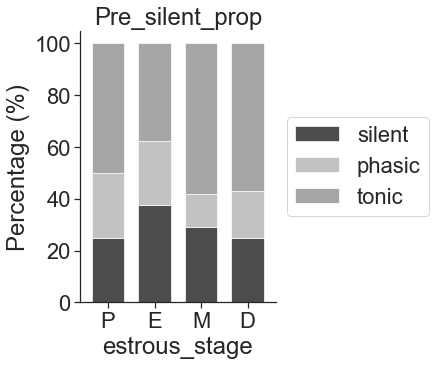

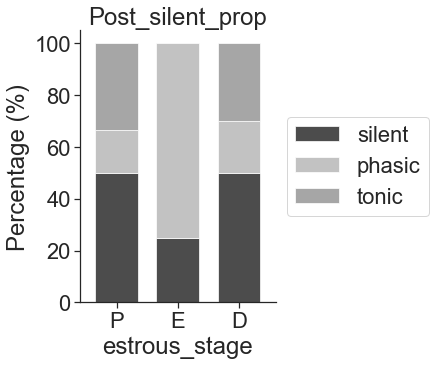

In [22]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero_reclassified.isin(['silent', 'phasic', 'tonic'])] # was previously I_zero...
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg+']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero_reclassified', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', 
            kind = 'bar', 
            stacked = True,  
            mark_right = False,
            color = ['black', 'darkgray','gray'],
            figsize = (3.5,5), alpha = 0.7, width = 0.7)
 
        
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')

I_zero_reclassified  phasic  silent  tonic  All
estrous_stage                                  
?                         1       1      2    4
D                         5       7     16   28
E                         2       3      3    8
M                         3       7     14   24
P                         6       6     12   24
VS to be stained          0       0      1    1
no VS                     1       2      9   12
not taken                 1       2      1    4
All                      19      28     58  105
0.9417552913501139


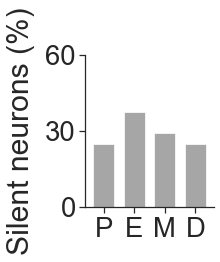

In [45]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero_reclassified.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg-','Agg+']),'Behaviour_6hFD'] = 'Post'
ephys_stats = ephys.copy()

for state in ['Pre']: #Post Pre --> change filename accordingly
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero_reclassified', cols) # was previously I_zero
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    

    sns.set(font_scale=2.5)
    sns.set_style("ticks")
    silent_prop.plot(x = 'estrous_stage', y = 'silent',
            kind = 'bar', 
            stacked = False,  
            mark_right = False,
            color = ['gray'],
            figsize = (2.3,2.8), alpha = 0.7, width = 0.7)
 
        
    
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Silent neurons (%)', labelpad=10)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.xlabel(None)
    plt.ylim(0,60) 
    plt.yticks([0, 60, 30])
    ax.get_legend().remove()

    plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/silent_estrous_pre.pdf',
                dpi=300,bbox_inches='tight', transparent=True)

In [38]:
# STATS - PRE =================================================

ephys_pre = ephys_stats[ephys_stats['Behaviour_6hFD'] == 'Pre']

# Group the data by 'estrous_stage' and 'I_zero_reclassified', and count the occurrences
grouped_counts = ephys_pre.groupby(['estrous_stage', 'I_zero_reclassified']).size().unstack(fill_value=0)

# Filter out 'active' entries (phasic and tonic)
grouped_counts['active'] = grouped_counts.get('phasic', 0) + grouped_counts.get('tonic', 0)

# Drop the individual counts for 'phasic' and 'tonic'
grouped_counts.drop(columns=['phasic', 'tonic'], inplace=True, errors='ignore')

# Add a column for 'silent' if it doesn't exist
if 'silent' not in grouped_counts.columns:
    grouped_counts['silent'] = 0

# Filter to include only 'P', 'M', 'E', 'D'
pre_counts = grouped_counts.loc[grouped_counts.index.isin(['P', 'M', 'E', 'D'])]

print(pre_counts)

# Fisher's exact test 
def fisher_test(group1, group2, table):
    contingency_table = table.loc[[group1, group2], ['silent', 'active']].values
    oddsratio, p_value = stats.fisher_exact(contingency_table)
    return oddsratio, p_value

groups = ['P', 'M', 'E', 'D']

results = []
for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        oddsratio, p_value = fisher_test(group1, group2, pre_counts)
        results.append((group1, group2, oddsratio, p_value))

results_pre_df = pd.DataFrame(results, columns=['Group1', 'Group2', 'OddsRatio', 'PValue'])
print(f"Pre stats: \n{results_pre_df}")

# STATS - POST =================================================

ephys_post = ephys_stats[ephys_stats['Behaviour_6hFD'] == 'Post']

# Group the data by 'estrous_stage' and 'I_zero_reclassified', and count the occurrences
grouped_counts = ephys_post.groupby(['estrous_stage', 'I_zero_reclassified']).size().unstack(fill_value=0)

# Filter out 'active' entries (phasic and tonic)
grouped_counts['active'] = grouped_counts.get('phasic', 0) + grouped_counts.get('tonic', 0)

# Drop the individual counts for 'phasic' and 'tonic'
grouped_counts.drop(columns=['phasic', 'tonic'], inplace=True, errors='ignore')

# Add a column for 'silent' if it doesn't exist
if 'silent' not in grouped_counts.columns:
    grouped_counts['silent'] = 0

# Filter to include only 'P', 'M', 'E', 'D'
post_counts = grouped_counts.loc[grouped_counts.index.isin(['P', 'M', 'E', 'D'])]

print(post_counts)

results = []
for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        oddsratio, p_value = fisher_test(group1, group2, post_counts)
        results.append((group1, group2, oddsratio, p_value))

results_post_df = pd.DataFrame(results, columns=['Group1', 'Group2', 'OddsRatio', 'PValue'])
print(f"Post stats: \n{results_post_df}")

I_zero_reclassified  silent  active
estrous_stage                      
D                         7      21
E                         3       5
M                         7      17
P                         6      18
Pre stats: 
  Group1 Group2  OddsRatio    PValue
0      P      M   0.809524  1.000000
1      P      E   0.555556  0.654498
2      P      D   1.000000  1.000000
3      M      E   0.686275  0.680786
4      M      D   1.235294  0.763512
5      E      D   1.800000  0.657626
I_zero_reclassified  silent  active
estrous_stage                      
D                         5       5
E                         1       3
M                         1       9
P                         6      12
Post stats: 
  Group1 Group2  OddsRatio    PValue
0      P      M   4.500000  0.364244
1      P      E   1.500000  1.000000
2      P      D   0.500000  0.444263
3      M      E   0.333333  0.505495
4      M      D   0.111111  0.140867
5      E      D   0.333333  0.580420


In [ ]:
import scipy as sp
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

r, p = sp.stats.pearsonr(corr['switching probability'], corr['silent'])
print(r, p)
sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

In [ ]:
# import multiple comparison
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

# ls = ['Ih_at_-120mV']

for state in ['Pre']:  #change Pre/Post accordingly!
    for column in ls:
        # state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df = ephys.copy()
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        state_df = state_df[state_df.Behaviour_6hFD == state]
        
        try:

            _, p = stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'E'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'D'].dropna())
        
            
            

            
            if p < 0.05:
                print(column , p)
                state_df = state_df.loc[:, ['estrous_stage', column]].dropna()
                multiple_comp_result = pairwise_tukeyhsd(endog=state_df[column],
                                         groups=state_df['estrous_stage'],
                                        alpha=0.05)
                print(multiple_comp_result.summary())

                fig,ax = plt.subplots(figsize = (2.5,3))
                sns.swarmplot(x='estrous_stage', y =column, data= state_df, alpha = 0.3, color = 'black')
                sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7), width = 0.5, palette = ['gray'])
                sns.despine()
                plt.xticks(rotation = 45, fontsize = 20)
                # plt.ylabel('Ih current (pA)', fontsize = 25)
                plt.xlabel('')
            
                # plt.title(f'{state}_{column}', pad = 20)
                plt.savefig(f'output_figures/{state}_{column}.png',dpi = 300, bbox_inches = 'tight')
            
            plt.show()
        except Exception:
            continue

In [ ]:
# Ih - estrous Pre/Post
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = state_df, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = state_df, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
group_counts = state_df['estrous_stage'].value_counts()
print(f"Cell numbers: \n{group_counts}")
unique_counts = state_df.groupby('estrous_stage')['ID_mouse'].nunique()
print(f"Mouse numbers: \n{unique_counts}")

In [ ]:
import scipy as sp
cols = ['no', 'yes']
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'


estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
ephys_pre = ephys[ephys.Behaviour_6hFD == 'Pre']

for column in ['cat_categ', 'IH', 'Adaptive']:
    esprop = proportion(ephys_pre, 'estrous_stage', column, cols)
    esprop['estrous_stage'] = pd.Categorical(esprop['estrous_stage'], ['P', 'E', 'M', 'D'])
    esprop = esprop.sort_values(by = ['estrous_stage']).dropna()
    prop_plot(esprop, 'estrous_stage')
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on = 'estrous_stage')
    r, p = sp.stats.pearsonr(corr['switching probability'], corr['no'])
    print(r, p)

    sns.lmplot(x = 'no', y = 'switching probability', data = corr, ci = None, )
    plt.ylim([0, 100])
    plt.xlabel(f'% {column}')
    plt.ylabel('Switching probability(%)')
#     plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/{column}_switching_corr.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)
    plt.show()

In [ ]:

cols = ['no', 'yes']
estrous_stages = ['P', 'E', 'M', 'D']
ih_prop = proportion(ephys_pre, 'estrous_stage', 'IH', cols)
ih_est_mean = ephys_pre.groupby('estrous_stage')['Ih_at_-120mV'].mean().reset_index()
adaptive_prop = proportion(ephys_pre, 'estrous_stage', 'Adaptive', cols)
merged_df = pd.merge(ih_est_mean, adaptive_prop, on = 'estrous_stage')
merged_df = merged_df[merged_df.estrous_stage.isin(estrous_stages)]


r, p = sp.stats.pearsonr(merged_df['Ih_at_-120mV'], merged_df['yes'])
print(r, p)

sns.lmplot(x = 'Ih_at_-120mV', y = 'yes', data = merged_df)
# plt.ylim([0, /100])
plt.xlabel('% with IH current')
plt.ylabel('% with DB')
plt.show()

## Individual plots

### Pre

In [ ]:
# We're plotting by estrous state from all 'Pre' values here
ephys_estrous = ephys[ephys['Behaviour_6hFD'] == 'Pre']

In [ ]:
print(f"Number of P neurons: {(ephys_estrous['estrous_stage'] == 'P').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_estrous['estrous_stage'] == 'E').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_estrous['estrous_stage'] == 'M').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_estrous['estrous_stage'] == 'D').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

In [ ]:
# Membrane voltage - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Vm_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats - one-way ANOVA
groups = ephys_estrous.groupby('estrous_stage')['Vm'].apply(lambda x: x.dropna().tolist())
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

In [ ]:
# Input resistance - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ri_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# Firing frequency - estrous Pre

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first.
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_estrous2 = ephys_estrous[ephys_estrous['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_estrous2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/ff_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats - one-way ANOVA
groups = ephys_estrous2.groupby('estrous_stage')['Firing_freq_(Hz)_I0'].apply(lambda x: x.dropna().tolist())
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

### Post (Agg+/- pooled)

In [ ]:
# We're plotting by estrous state from all 'Agg+' and 'Agg-' values here
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_post = ephys[(ephys['Behaviour_6hFD'] == 'Agg+') | (ephys['Behaviour_6hFD'] == 'Agg-')]

In [ ]:
print(f"Number of P neurons: {(ephys_post['estrous_stage'] == 'P').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_post['estrous_stage'] == 'E').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_post['estrous_stage'] == 'M').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_post['estrous_stage'] == 'D').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

In [ ]:
# Ih - Post
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=1)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ih_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats - one-way ANOVA
groups = ephys_post.groupby('estrous_stage')['Ih_at_-120mV'].apply(lambda x: x.dropna().tolist())
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

In [ ]:
# Membrane voltage - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Vm_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats - one-way ANOVA
groups = ephys_post.groupby('estrous_stage')['Vm'].apply(lambda x: x.dropna().tolist())
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

In [ ]:
# Input resistance - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ri_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats - one-way ANOVA
groups = ephys_post.groupby('estrous_stage')['Input_Resistance'].apply(lambda x: x.dropna().tolist())
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

In [ ]:
# Firing frequency - estrous Post

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first. NOTE THAT THIS REMOVES E.G. 'P to E' ETC. 
#- IT MIGHT BE BETTER TO RECLASSIFY THOSE
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_post2 = ephys_post[ephys_post['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_post2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/ff_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats - one-way ANOVA
groups = ephys_post2.groupby('estrous_stage')['Firing_freq_(Hz)_I0'].apply(lambda x: x.dropna().tolist())
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

# Tukey HSD 
ephys_post3 = ephys_post2.dropna(subset=['Firing_freq_(Hz)_I0', 'estrous_stage'])
tukey_results = pairwise_tukeyhsd(ephys_post3['Firing_freq_(Hz)_I0'], ephys_post3['estrous_stage'])
print(tukey_results)

# NPY administration

In [ ]:
# reload data and convert all instances of NPY application to 'npy'
# UPDATE: use updated npy_100 column!
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_npy = ephys.copy()
# ephys_npy['Behaviour_6hFD'] = ephys_npy['Behaviour_6hFD'].replace(['npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100'], 'npy')


In [ ]:
print(f"Number of Pre neurons: {(ephys_npy['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of NPY neurons: {(ephys_npy['Behaviour_6hFD'] == 'npy_100').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'npy_100']['ID_mouse'].nunique()} mice")

In [ ]:
# ephys_npy

In [ ]:
ephys_npy.Behaviour_6hFD.unique()

In [ ]:
# Membrane voltage / RMP + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# Ih + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats U test
pre_data = ephys_npy[ephys_npy['Behaviour_6hFD'] == 'Pre']['Ih_at_-120mV'].dropna()
npy_100_data = ephys_npy[ephys_npy['Behaviour_6hFD'] == 'npy_100']['Ih_at_-120mV'].dropna()
u_statistic, p_value = mannwhitneyu(pre_data, npy_100_data)
print("Mann-Whitney U test p-value:", p_value)

In [ ]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'npy_100']
silent_npy = proportion(ephys_npy[ephys_npy.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_npy['Behaviour_6hFD'] = pd.Categorical(silent_npy['Behaviour_6hFD'], cat)
silent_npy = silent_npy.sort_values(by = ['Behaviour_6hFD'])

In [ ]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_npy, x="Behaviour_6hFD", y="silent", order=['Pre', 'npy_100'], palette = npy, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('Silent neurons (%)', labelpad=10)
g.set_xticklabels(('Pre', 'NPY'), rotation=45)
plt.xlabel('')
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0,100)
# ax.yaxis.set_major_locator(plt.MaxNLocator(5))
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# subset df for those groups needed for firing freq. plot
ephys_npy_ff = ephys_npy.loc[(ephys_npy['Behaviour_6hFD'] == 'Pre') | (ephys_npy['Behaviour_6hFD'] == 'npy_100')]

In [ ]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_npy_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = npy, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats U test
pre_ff = ephys_npy_ff[ephys_npy_ff['Behaviour_6hFD'] == 'Pre']['Firing_freq_(Hz)_I0'].dropna()
npy_ff = ephys_npy_ff[ephys_npy_ff['Behaviour_6hFD'] == 'npy_100']['Firing_freq_(Hz)_I0'].dropna()
u_statistic, p_value = mannwhitneyu(pre_ff, npy_ff)
print("Mann-Whitney U test p-value:", p_value)

# AgRP administration

In [ ]:
# reload data and convert all instances of AgRP application to 'agrp'
# UPDATE: use the updated agrp_100 column!
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_agrp = ephys.copy()
ephys_agrp['Behaviour_6hFD'] = ephys_agrp['Behaviour_6hFD'].replace(['agrp_100_paired', 'agrp_100'], 'agrp')

In [ ]:
print(f"Number of Pre neurons: {(ephys_agrp['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of AgRP neurons: {(ephys_agrp['Behaviour_6hFD'] == 'agrp').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'agrp']['ID_mouse'].nunique()} mice")

In [ ]:
# Membrane voltage / RMP + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order=['Pre', 'agrp'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order = ['Pre', 'agrp'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_agrp.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# Ih + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order=['Pre', 'agrp'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order = ['Pre', 'agrp'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats U test
pre_sag = ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'Pre']['Ih_at_-120mV'].dropna()
agrp_sag = ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'agrp']['Ih_at_-120mV'].dropna()
u_statistic, p_value = mannwhitneyu(pre_sag, agrp_sag)
print("Mann-Whitney U test p-value:", p_value)

In [ ]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order=['Pre', 'agrp'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order = ['Pre', 'agrp'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_agrp.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats U test
pre_ri = ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'Pre']['Input_Resistance'].dropna()
agrp_ri = ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'agrp']['Input_Resistance'].dropna()
u_statistic, p_value = mannwhitneyu(pre_ri, agrp_ri)
print("Mann-Whitney U test p-value:", p_value)

In [ ]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'agrp']
silent_agrp = proportion(ephys_agrp[ephys_agrp.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_agrp['Behaviour_6hFD'] = pd.Categorical(silent_agrp['Behaviour_6hFD'], cat)
silent_agrp = silent_agrp.sort_values(by = ['Behaviour_6hFD'])

In [ ]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_agrp, x="Behaviour_6hFD", y="silent", order=['Pre', 'agrp'], palette = agrp, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('Silent neurons (%)', labelpad=10)
g.set_xticklabels(('Pre', 'AgRP'), rotation=45)
plt.xlabel('')
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0,100)
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# subset df for those groups needed for firing freq. plot
ephys_agrp_ff = ephys_agrp.loc[(ephys_agrp['Behaviour_6hFD'] == 'Pre') | (ephys_agrp['Behaviour_6hFD'] == 'agrp')]

In [ ]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_agrp_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = agrp, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [ ]:
# stats U test
pre_ff = ephys_agrp_ff[ephys_agrp_ff['Behaviour_6hFD'] == 'Pre']['Firing_freq_(Hz)_I0'].dropna()
agrp_ff = ephys_agrp_ff[ephys_agrp_ff['Behaviour_6hFD'] == 'agrp']['Firing_freq_(Hz)_I0'].dropna()
u_statistic, p_value = mannwhitneyu(pre_ff, agrp_ff)
print("Mann-Whitney U test p-value:", p_value)